In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report

In [27]:
raw_df = pd.read_csv(r"/Users/loganheydt/Desktop/Data/GitHub/Titanic-Prediction/Data/test.csv")

df = pd.read_csv(r"/Users/loganheydt/Desktop/Data/GitHub/Titanic-Prediction/Data/train.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [28]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [29]:
#  # Name string to title
# df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.')
# df['Title'].value_counts()

In [30]:
drop_cols = ['PassengerId','Cabin', 'Name']
one_hot_cols = ['Sex', 'Embarked']
impute_cols = ['Age']

# Need to drop the 2 null embarked 

In [31]:
def transform_data(df):

    modeling_df = df.copy()

    # Ticket string to number
    modeling_df['Ticket'] = modeling_df['Ticket'].str.extract(r'(\d+)\s*$').astype(float)

    # # Name string to title
    # modeling_df['Title'] = modeling_df['Name'].str.extract(' ([A-Za-z]+)\.')

    modeling_df['is_child'] = (modeling_df['Age'] < 18).astype(int)

    modeling_df['family_size'] = modeling_df['SibSp'] + df['Parch'] + 1

    modeling_df['is_alone'] = (modeling_df['family_size'] ==1).astype(int)

    # Dropped null Embarked
    modeling_df = modeling_df.dropna(subset=['Embarked', 'Ticket'])

    # Imputed Age
    imputer = SimpleImputer(strategy='mean')
    imputer.fit(modeling_df[impute_cols])
    x_imputed = imputer.transform(modeling_df[impute_cols])
    modeling_df[impute_cols] = pd.DataFrame(x_imputed, columns=impute_cols, index=modeling_df.index)

    # One Hot Encoding
    encoder = OneHotEncoder(sparse_output=False)
    one_hot_encoded = encoder.fit_transform(modeling_df[one_hot_cols])
    one_hot_df = pd.DataFrame(one_hot_encoded, columns= encoder.get_feature_names_out(one_hot_cols), index=modeling_df.index)
    modeling_df = pd.concat([modeling_df.drop(columns=one_hot_cols, axis=1), one_hot_df], axis=1)

    # Dropped unneccesary columns
    modeling_df.drop(columns=drop_cols, inplace= True)

    return modeling_df

modeling_df = transform_data(df)
test_df = transform_data(raw_df)

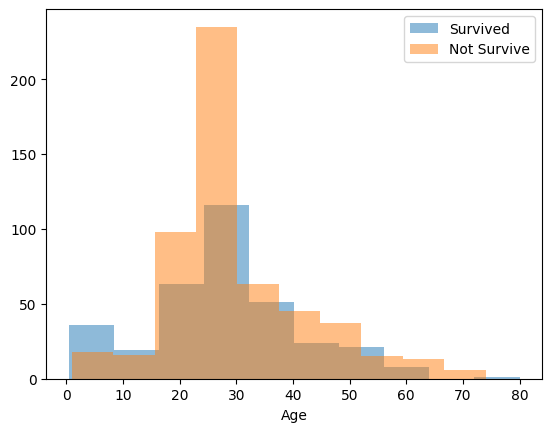

In [32]:
survived = modeling_df[modeling_df['Survived'] == 1]
not_survive = modeling_df[modeling_df['Survived'] == 0]

plt.hist(survived['Age'], alpha=.5, label='Survived')
plt.hist(not_survive['Age'], alpha=.5,  label= 'Not Survive')
plt.xlabel('Age')
plt.legend()
plt.show()

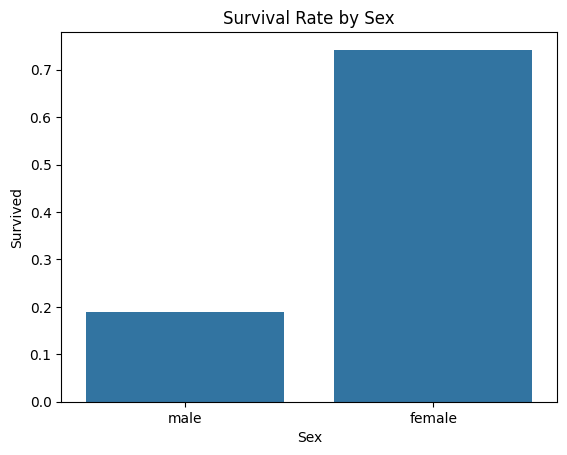

In [33]:
sns.barplot(x='Sex', y='Survived', data=df, errorbar=None)
plt.title("Survival Rate by Sex")
plt.show()

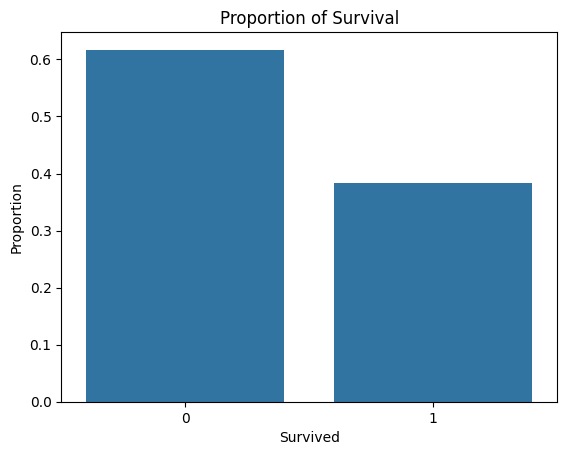

In [34]:
target_dist = pd.DataFrame(modeling_df['Survived'].value_counts(normalize=True))

target_dist.columns = ['Proportion']

sns.barplot(x='Survived', y='Proportion', data=target_dist)
plt.title('Proportion of Survival')
plt.xlabel('Survived')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.show()

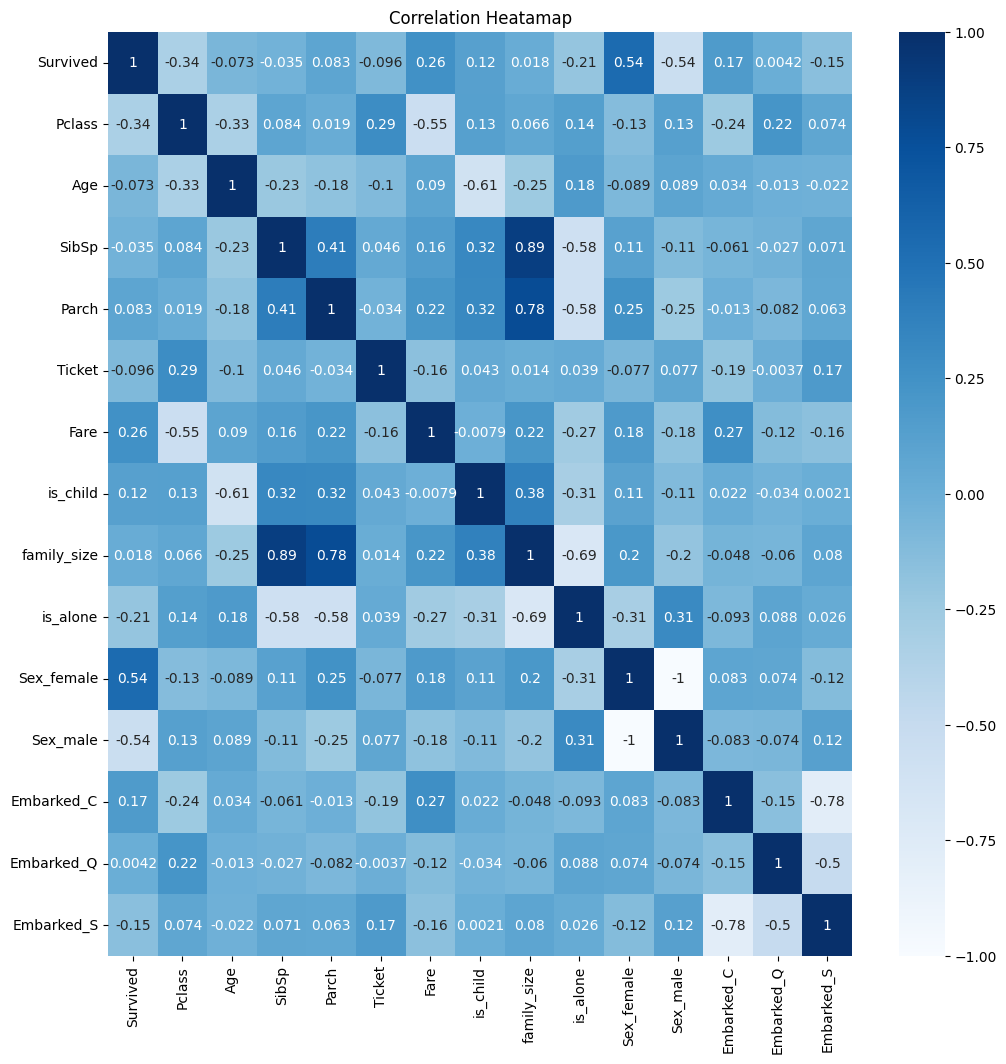

In [35]:
plt.figure(figsize=(12,12))
corr = modeling_df.corr()
sns.heatmap(corr, cmap='Blues', annot=True)
plt.title("Correlation Heatamap")
plt.show()

In [36]:
modeling_df.describe()

,Survived,Pclass,Age,SibSp,Parch,Ticket,Fare,is_child,family_size,is_alone,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
count,885.000000,885.000000,885.000000,885.000000,885.000000,8.850000e+02,885.000000,885.000000,885.000000,885.000000,885.000000,885.000000,885.000000,885.000000,885.000000
mean,0.383051,2.308475,29.627359,0.526554,0.384181,2.987459e+05,32.241751,0.127684,1.910734,0.600000,0.352542,0.647458,0.189831,0.087006,0.723164
std,0.486405,0.835298,12.973693,1.105634,0.808173,6.582991e+05,49.762788,0.333926,1.617197,0.490175,0.478032,0.478032,0.392389,0.282003,0.447688
min,0.000000,1.000000,0.420000,0.000000,0.000000,3.000000e+00,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,1.487900e+04,7.925000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,3.000000,29.627359,0.000000,0.000000,1.120590e+05,14.454200,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000
75%,1.000000,3.000000,35.000000,1.000000,0.000000,3.470820e+05,31.000000,0.000000,2.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,3.101317e+06,512.329200,1.000000,11.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [37]:
y = modeling_df['Survived']
x = modeling_df.drop(columns='Survived')

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.3)

# x_train.isnull().sum()
model = LogisticRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.67      0.95      0.79       167
           1       0.73      0.22      0.34        99

    accuracy                           0.68       266
   macro avg       0.70      0.59      0.57       266
weighted avg       0.70      0.68      0.62       266



/Users/loganheydt/Desktop/Data/GitHub/.venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
